# Proyecto Final IA - Predicción de Evolución del Rendimiento en FIFA

Integrantes:
- Luis Moreno Guitierrez
- Antonia Muñoz Jiménez
- Juan Carlos Fernández Vanoy

### Parte 1 — Cargar el dataset

a. Descargar y descomprimir

In [1]:
!kaggle datasets download -d stefanoleone992/fifa-20-complete-player-dataset
!unzip fifa-20-complete-player-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/stefanoleone992/fifa-20-complete-player-dataset
License(s): CC0-1.0
100% 14.5M/14.5M [00:00<00:00, 73.4MB/s]

Archive:  fifa-20-complete-player-dataset.zip
  inflating: players_15.csv          
  inflating: players_16.csv          
  inflating: players_17.csv          
  inflating: players_18.csv          
  inflating: players_19.csv          
  inflating: players_20.csv          
  inflating: teams_and_leagues.csv   


b. Ver qué archivos hay

In [2]:
import os
os.listdir()

['.config',
 'players_17.csv',
 'players_18.csv',
 'players_20.csv',
 'fifa-20-complete-player-dataset.zip',
 'players_15.csv',
 'players_19.csv',
 'players_16.csv',
 'teams_and_leagues.csv',
 'sample_data']

c. Cargar y procesar

In [3]:
import pandas as pd
import numpy as np

# cargar TODOS los CSVs y combinarlos
dfs = []
for year in range(15, 21):
    try:
        temp = pd.read_csv(f"players_{year}.csv", low_memory=False)
        temp['fifa_version'] = year
        dfs.append(temp)
    except: pass

df = pd.concat(dfs, ignore_index=True)
print(df.shape)
print(df.columns.tolist())  # verifica que exista 'overall', 'short_name', etc.

(100995, 105)
['sofifa_id', 'player_url', 'short_name', 'long_name', 'age', 'dob', 'height_cm', 'weight_kg', 'nationality', 'club', 'overall', 'potential', 'value_eur', 'wage_eur', 'player_positions', 'preferred_foot', 'international_reputation', 'weak_foot', 'skill_moves', 'work_rate', 'body_type', 'real_face', 'release_clause_eur', 'player_tags', 'team_position', 'team_jersey_number', 'loaned_from', 'joined', 'contract_valid_until', 'nation_position', 'nation_jersey_number', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes', 'gk_speed', 'gk_positioning', 'player_traits', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance', 'power_shot_p

### Parte 2 — Ajustes y EDA

a. Limpieza y variable objetivo

In [4]:
# aqui eliminar columnas irrelevantes
cols_irrelevantes = ['player_url', 'real_face', 'nation_position',
                     'nation_jersey_number', 'player_tags', 'player_traits',
                     'loaned_from', 'joined', 'contract_valid_until']
df.drop(columns=[c for c in cols_irrelevantes if c in df.columns], inplace=True)

#  aqui eliminar nulos en columnas clave
# esto es es 'player_positions', no 'position'
df.dropna(subset=['overall', 'age', 'player_positions'], inplace=True)

# variable objetivo
df_sorted = df.sort_values(['short_name', 'fifa_version'])
df_sorted['overall_prev'] = df_sorted.groupby('short_name')['overall'].shift(1)
df_sorted['diff'] = df_sorted['overall'] - df_sorted['overall_prev']

def classify(diff):
    if pd.isna(diff): return np.nan
    if diff > 0:  return 'sube'
    if diff == 0: return 'estable'
    return 'baja'

df_sorted['target'] = df_sorted['diff'].apply(classify)
df_sorted.dropna(subset=['target'], inplace=True)

print(df_sorted['target'].value_counts())
print(f"\nDataset final: {df_sorted.shape}")

target
sube       34581
baja       18401
estable    13566
Name: count, dtype: int64

Dataset final: (66548, 99)


b. EDA

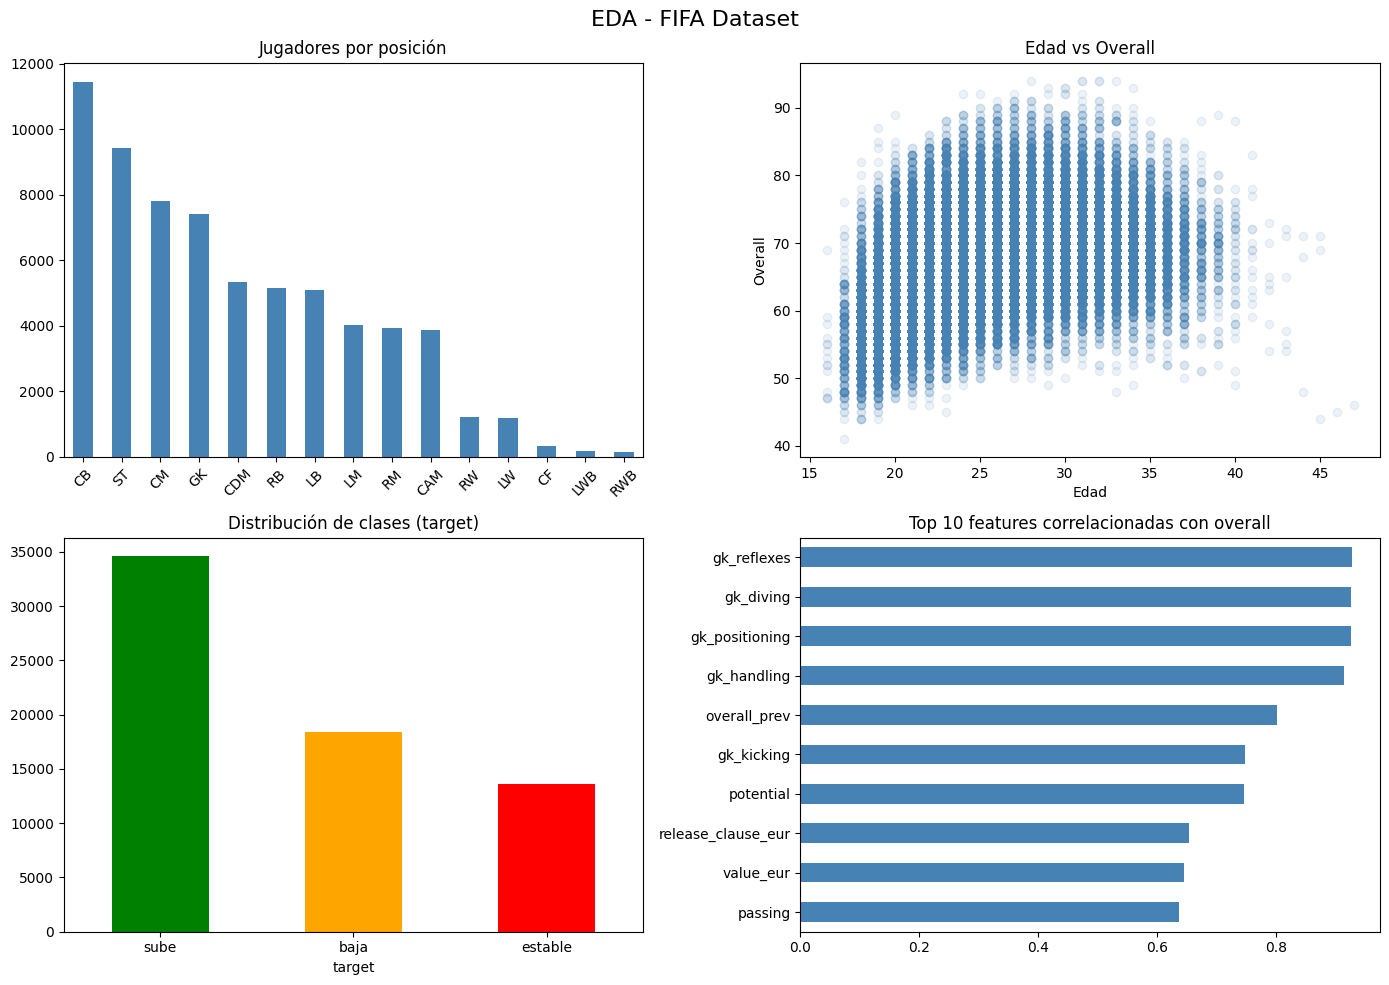

Grafica guardada como eda.png


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# posición principal (tomar la primera de la lista)
df_sorted['pos_main'] = df_sorted['player_positions'].str.split(',').str[0].str.strip()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA - FIFA Dataset', fontsize=16)

# 1. distribución por posicion
df_sorted['pos_main'].value_counts().head(15).plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Jugadores por posición')
axes[0,0].set_xlabel('')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. edad vs overall
axes[0,1].scatter(df_sorted['age'], df_sorted['overall'], alpha=0.1, color='steelblue')
axes[0,1].set_title('Edad vs Overall')
axes[0,1].set_xlabel('Edad')
axes[0,1].set_ylabel('Overall')

# 3. desbalance de clases
colors = ['green', 'orange', 'red']
df_sorted['target'].value_counts().plot(kind='bar', ax=axes[1,0], color=colors)
axes[1,0].set_title('Distribución de clases (target)')
axes[1,0].tick_params(axis='x', rotation=0)

# 4. correlaciones top features con overall
num_cols = df_sorted.select_dtypes(include='number').columns
corr = df_sorted[num_cols].corr()['overall'].drop('overall').sort_values()
corr.tail(10).plot(kind='barh', ax=axes[1,1], color='steelblue')
axes[1,1].set_title('Top 10 features correlacionadas con overall')

plt.tight_layout()
plt.savefig('eda.png', dpi=150)
plt.show()
print("Grafica guardada como eda.png")

c. Corregimos el heatmap

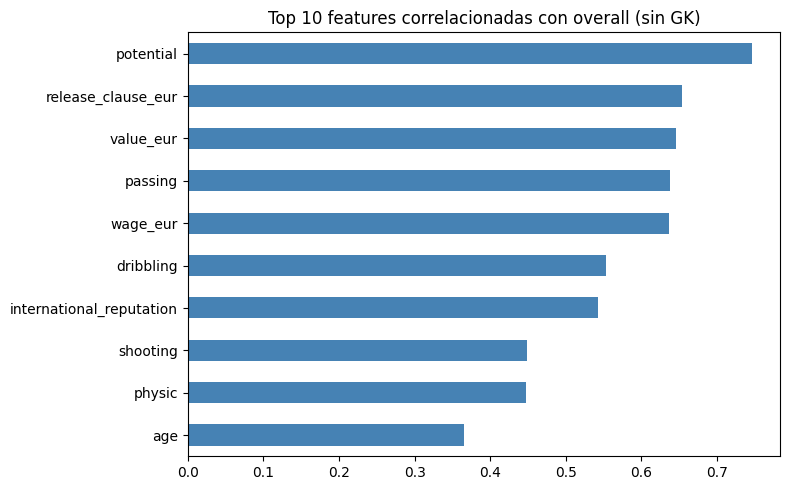

In [6]:
# excluir columnas problematicas del analisis de correlación
excluir = ['overall_prev', 'diff', 'sofifa_id',
           'gk_diving', 'gk_handling', 'gk_kicking',
           'gk_reflexes', 'gk_speed', 'gk_positioning',
           'goalkeeping_diving', 'goalkeeping_handling',
           'goalkeeping_kicking', 'goalkeeping_positioning',
           'goalkeeping_reflexes']

num_cols = df_sorted.select_dtypes(include='number').columns
num_cols_clean = [c for c in num_cols if c not in excluir]

corr = df_sorted[num_cols_clean].corr()['overall'].drop('overall').sort_values()

plt.figure(figsize=(8, 5))
corr.tail(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 features correlacionadas con overall (sin GK)')
plt.tight_layout()
plt.savefig('correlaciones.png', dpi=150)
plt.show()

d. Pipeline

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

FEATURES = ['potential', 'release_clause_eur', 'value_eur', 'wage_eur',
            'passing', 'dribbling', 'international_reputation',
            'shooting', 'physic', 'age']

X = df_sorted[FEATURES]
y = df_sorted['target']

# split PRIMERO
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# pipeline DESPUES (fit solo en train)
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

X_train_p = pipeline.fit_transform(X_train)
X_test_p  = pipeline.transform(X_test)

print(f"Train: {X_train_p.shape}")
print(f"Test:  {X_test_p.shape}")
print(f"\nClases en train:\n{y_train.value_counts()}")

Train: (53238, 10)
Test:  (13310, 10)

Clases en train:
target
sube       27664
baja       14721
estable    10853
Name: count, dtype: int64


e. Descargamos archivos

In [8]:
# celda extra
import joblib

joblib.dump(pipeline, 'pipeline_preprocesamiento.pkl')
joblib.dump((X_train_p, X_test_p, y_train, y_test), 'datos_procesados.pkl')
joblib.dump(df_sorted, 'df_fifa_limpio.pkl')  # Persona 3 lo necesita para buscar jugadores

# descargar
from google.colab import files
files.download('pipeline_preprocesamiento.pkl')
files.download('datos_procesados.pkl')
files.download('df_fifa_limpio.pkl')
files.download('eda.png')
files.download('correlaciones.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Modelo ML

a. Setup

In [9]:
!pip install lightgbm shap --quiet

In [10]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from lightgbm import LGBMClassifier
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, f1_score,
    roc_auc_score, ConfusionMatrixDisplay
)

SEED = 42

In [11]:
# Cargar datos procesadoa
X_train, X_test, y_train, y_test = joblib.load('datos_procesados.pkl')

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"\nClases train:\n{pd.Series(y_train).value_counts()}")

Train: (53238, 10) | Test: (13310, 10)

Clases train:
target
sube       27664
baja       14721
estable    10853
Name: count, dtype: int64


b. Baselines

In [12]:
# BASELINE — Clasificador por mayoría de clase
baseline = DummyClassifier(strategy='most_frequent', random_state=SEED)
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

print("=" * 50)
print("BASELINE (mayoría de clase)")
print("=" * 50)
print(classification_report(y_test, y_pred_base))
print(f"F1 macro: {f1_score(y_test, y_pred_base, average='macro'):.4f}")

BASELINE (mayoría de clase)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

        baja       0.00      0.00      0.00      3680
     estable       0.00      0.00      0.00      2713
        sube       0.52      1.00      0.68      6917

    accuracy                           0.52     13310
   macro avg       0.17      0.33      0.23     13310
weighted avg       0.27      0.52      0.36     13310

F1 macro: 0.2280


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [13]:
# MODELO 1 — Regresión Logística
# Segundo baseline más informativo que el dummy
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',   # maneja el desbalance
    random_state=SEED
)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=" * 50)
print("REGRESIÓN LOGÍSTICA")
print("=" * 50)
print(classification_report(y_test, y_pred_lr))
print(f"F1 macro: {f1_score(y_test, y_pred_lr, average='macro'):.4f}")

REGRESIÓN LOGÍSTICA
              precision    recall  f1-score   support

        baja       0.37      0.47      0.41      3680
     estable       0.26      0.25      0.26      2713
        sube       0.64      0.55      0.59      6917

    accuracy                           0.47     13310
   macro avg       0.42      0.43      0.42     13310
weighted avg       0.49      0.47      0.48     13310

F1 macro: 0.4222


c. LightGBM

In [14]:
# MODELO 2 — LightGBM (modelo principal)

# Calcular peso por clase para manejar el desbalance
from sklearn.utils.class_weight import compute_class_weight
clases = np.unique(y_train)
pesos = compute_class_weight('balanced', classes=clases, y=y_train)
pesos_dict = dict(zip(clases, pesos))
print(f"Pesos por clase: {pesos_dict}")

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        # early stopping para no sobreajustar
        __import__('lightgbm').early_stopping(50, verbose=False),
        __import__('lightgbm').log_evaluation(100)
    ]
)

y_pred_lgbm = lgbm.predict(X_test)

print("=" * 50)
print("LIGHTGBM")
print("=" * 50)
print(classification_report(y_test, y_pred_lgbm))
print(f"F1 macro: {f1_score(y_test, y_pred_lgbm, average='macro'):.4f}")

Pesos por clase: {'baja': np.float64(1.205488757557231), 'estable': np.float64(1.6351239288675943), 'sube': np.float64(0.6414835164835165)}
[100]	valid_0's multi_logloss: 1.0045
[200]	valid_0's multi_logloss: 1.00308
[300]	valid_0's multi_logloss: 1.00257


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LIGHTGBM
              precision    recall  f1-score   support

        baja       0.45      0.37      0.41      3680
     estable       0.29      0.43      0.35      2713
        sube       0.69      0.62      0.65      6917

    accuracy                           0.51     13310
   macro avg       0.48      0.47      0.47     13310
weighted avg       0.54      0.51      0.52     13310

F1 macro: 0.4684


In [15]:
# iteracion de early stopping
print(f"Árboles usados: {lgbm.best_iteration_}")

Árboles usados: 326


In [16]:
# Validación cruzada estratificada
# Stratified porque las clases están desbalanceadas (sube > baja > estable).
# Estimación más robusta que un solo split.

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = cross_validate(
    lgbm, X_train, y_train,
    cv=skf,
    scoring=['f1_macro', 'roc_auc_ovr_weighted'],
    n_jobs=-1
)

print("=" * 50)
print("VALIDACIÓN CRUZADA — LightGBM (5-fold estratificado)")
print("=" * 50)
print(f"F1 macro:          {cv_results['test_f1_macro'].mean():.4f} ± {cv_results['test_f1_macro'].std():.4f}")
print(f"AUC-ROC weighted:  {cv_results['test_roc_auc_ovr_weighted'].mean():.4f} ± {cv_results['test_roc_auc_ovr_weighted'].std():.4f}")

VALIDACIÓN CRUZADA — LightGBM (5-fold estratificado)
F1 macro:          0.4699 ± 0.0054
AUC-ROC weighted:  0.6883 ± 0.0043


In [17]:
# Comparativa de modelos
modelos = {
    'Baseline (mayoría)': y_pred_base,
    'Regresión Logística': y_pred_lr,
    'LightGBM': y_pred_lgbm
}

print("\n{'Modelo':<25} {'F1 macro':>10}")
print("-" * 37)
for nombre, preds in modelos.items():
    f1 = f1_score(y_test, preds, average='macro')
    print(f"{nombre:<25} {f1:>10.4f}")


{'Modelo':<25} {'F1 macro':>10}
-------------------------------------
Baseline (mayoría)            0.2280
Regresión Logística           0.4222
LightGBM                      0.4684


d. Visualizaciones

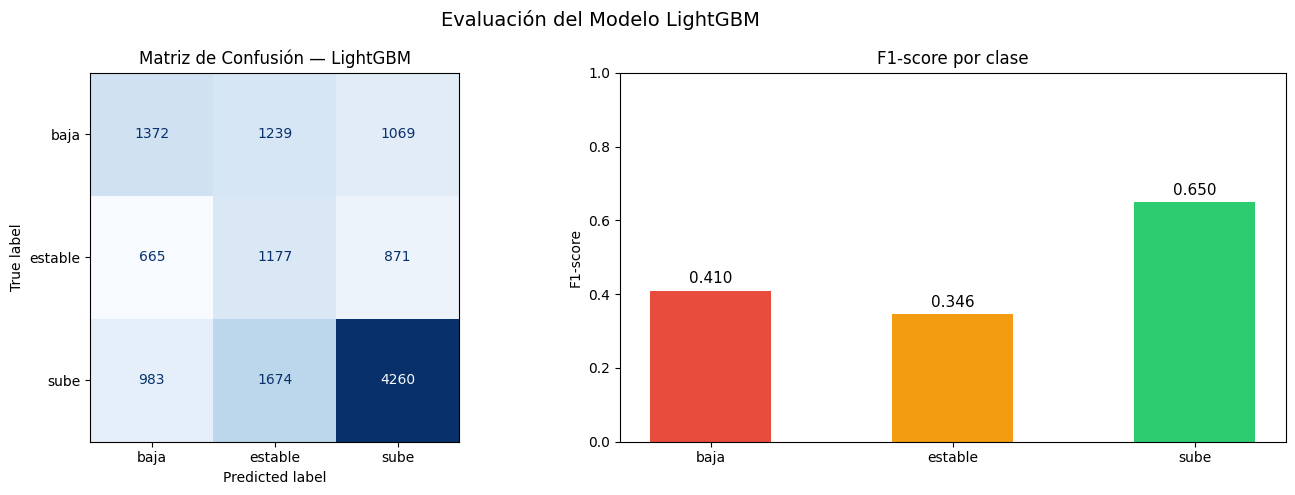

Guardado: evaluacion_modelo.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluación del Modelo LightGBM', fontsize=14)

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lgbm,
    display_labels=['baja', 'estable', 'sube'],
    ax=axes[0],
    colorbar=False,
    cmap='Blues'
)
axes[0].set_title('Matriz de Confusión — LightGBM')

# Comparativa F1 por clase
report = classification_report(y_test, y_pred_lgbm, output_dict=True)
clases_plot = ['baja', 'estable', 'sube']
f1s = [report[c]['f1-score'] for c in clases_plot]
colores = ['#e74c3c', '#f39c12', '#2ecc71']

axes[1].bar(clases_plot, f1s, color=colores, width=0.5)
axes[1].set_ylim(0, 1)
axes[1].set_title('F1-score por clase')
axes[1].set_ylabel('F1-score')
for i, v in enumerate(f1s):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('evaluacion_modelo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: evaluacion_modelo.png")

Calculando valores SHAP (puede tomar ~1 min)...
Tipo: <class 'numpy.ndarray'>
Shape: (500, 10, 3)
Shape final para plotting: (500, 10)
Shape X_test_sample: (500, 10)


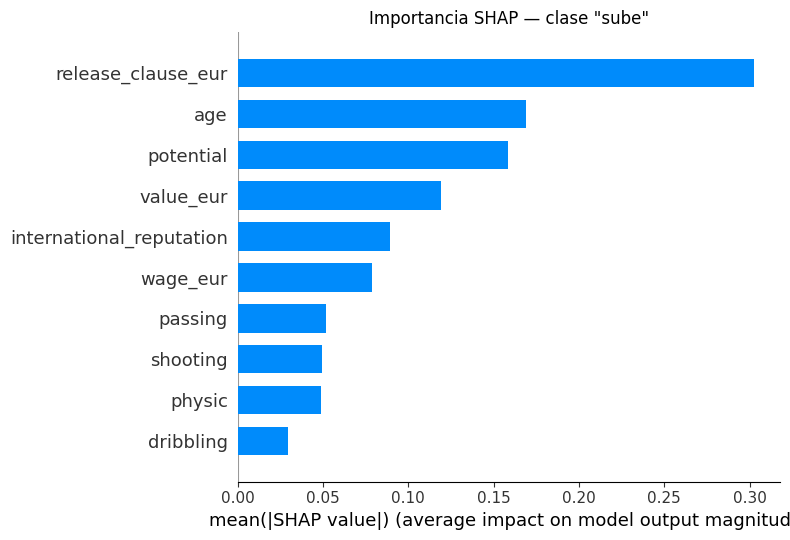

Guardado: shap_importancia.png


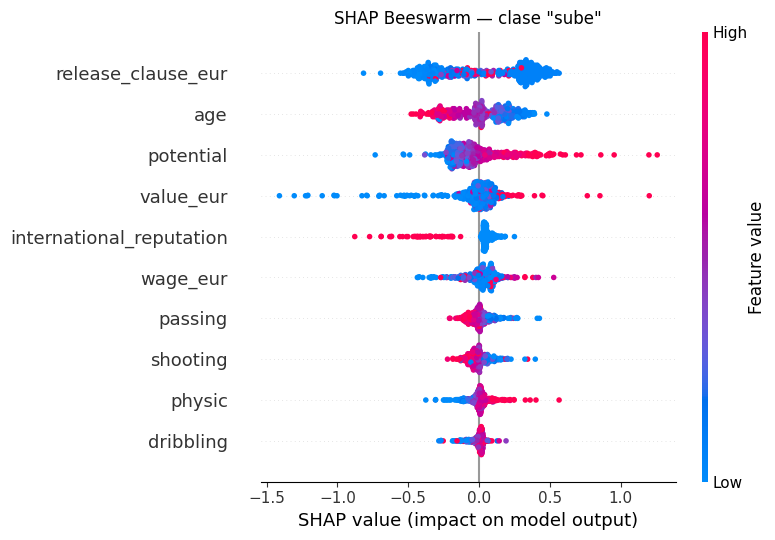

Guardado: shap_beeswarm.png


In [19]:
# SHAP — Importancia y explicabilidad
print("Calculando valores SHAP (puede tomar ~1 min)...")
explainer = shap.TreeExplainer(lgbm)

sample_idx = np.random.RandomState(SEED).choice(len(X_test), size=500, replace=False)
X_test_sample = X_test[sample_idx]

FEATURES = ['potential', 'release_clause_eur', 'value_eur', 'wage_eur',
            'passing', 'dribbling', 'international_reputation',
            'shooting', 'physic', 'age']

shap_values = explainer.shap_values(X_test_sample)

# Ver exactamente qué forma tiene shap_values
print(f"Tipo: {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"Cantidad de arrays: {len(shap_values)}")
    print(f"Shape de cada array: {shap_values[0].shape}")
    # LightGBM multiclase devuelve shape (n_samples, n_features, n_clases)
    # o una lista de (n_samples, n_features)
    shap_matriz = shap_values[2]  # clase 'sube'
else:
    print(f"Shape: {shap_values.shape}")
    # Nueva API de SHAP: shape (n_samples, n_features, n_clases)
    shap_matriz = shap_values[:, :, 2]  # clase 'sube'

print(f"Shape final para plotting: {shap_matriz.shape}")
print(f"Shape X_test_sample: {X_test_sample.shape}")

# Summary plot (importancia global)
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_matriz, X_test_sample,
    feature_names=FEATURES,
    plot_type='bar',
    show=False
)
plt.title('Importancia SHAP — clase "sube"')
plt.tight_layout()
plt.savefig('shap_importancia.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: shap_importancia.png")

# Beeswarm plot
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_matriz, X_test_sample,
    feature_names=FEATURES,
    show=False
)
plt.title('SHAP Beeswarm — clase "sube"')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: shap_beeswarm.png")

e. Exportar

In [20]:
# 1. El modelo entrenado para hacer predicciones
# 2. El explainer SHAP para generar los contextos del LLM
# 3. La lista de features para armar el input

joblib.dump(lgbm, 'modelo_lightgbm.pkl')
joblib.dump(explainer, 'shap_explainer.pkl')
joblib.dump(FEATURES, 'features.pkl')

from google.colab import files
files.download('modelo_lightgbm.pkl')
files.download('shap_explainer.pkl')
files.download('features.pkl')
files.download('evaluacion_modelo.png')
files.download('shap_importancia.png')
files.download('shap_beeswarm.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Prompt Engineering + LLM

In [22]:
!pip install groq streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 25.8 MB/s eta 0:00:00


In [23]:
from groq import Groq
import joblib
import pandas as pd
import numpy as np

# cargar archivos exportados por el proyecto
modelo = joblib.load('modelo_lightgbm.pkl')
explainer = joblib.load('shap_explainer.pkl')
features = joblib.load('features.pkl')
df = joblib.load('df_fifa_limpio.pkl')

# cliente Groq
client = Groq(
    api_key="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"
)

#####Función para buscar jugadores

In [24]:
def obtener_jugador(nombre):

    nombre = nombre.lower()

    coincidencias = df[
        df['short_name']
        .str.lower()
        .str.contains(nombre, na=False)
    ]

    if len(coincidencias) == 0:
        return None

    return coincidencias.iloc[0]

#####Predicción + SHAP

In [25]:
import numpy as np

def analizar_jugador(nombre):

    jugador = obtener_jugador(nombre)

    if jugador is None:
        return None

    X = pd.DataFrame(
    [jugador[features].values],
    columns=features
)

    # predicción
    pred_label = modelo.predict(X)[0] # This will be a string: 'baja', 'estable', or 'sube'

    # The 'clases' dictionary is not needed if we use pred_label directly.
    # pred_texto = clases[pred_label] would fail because pred_label is a string, not an int key.
    pred_texto = pred_label

    # Get the integer index for the predicted class label
    # modelo.classes_ stores the class labels in the order they were learned by the model
    # (e.g., ['baja', 'estable', 'sube'])
    pred_idx = np.where(modelo.classes_ == pred_label)[0][0]

    # SHAP
    shap_values = explainer.shap_values(X)

    if isinstance(shap_values, list):
        # For a single sample X and multi-class, explainer.shap_values(X) typically returns
        # a list of arrays, where each array is the SHAP values for one class,
        # with shape (num_features,).
        shap_clase = shap_values[pred_idx]
    else:
        # If shap_values is a single numpy array with shape (1, num_features, num_classes)
        # for a single sample X
        shap_clase = shap_values[0, :, pred_idx]

    # Ensure shap_clase is 1D for DataFrame creation
    if shap_clase.ndim > 1:
        shap_clase = shap_clase.flatten()

    importancia = pd.DataFrame({
        'feature': features,
        'impacto': shap_clase
    })

    importancia['abs'] = importancia['impacto'].abs()

    top = importancia.sort_values(
        'abs',
        ascending=False
    ).head(5)

    return {
        'jugador': jugador,
        'prediccion': pred_texto,
        'top_features': top
    }

#####Prompt Engineering

In [26]:
def generar_reporte(nombre):

    analisis = analizar_jugador(nombre)

    if analisis is None:
        return "Jugador no encontrado"

    jugador = analisis['jugador']
    pred = analisis['prediccion']
    top = analisis['top_features']

    factores = ""

    for _, row in top.iterrows():
        factores += f"- {row['feature']}: impacto {row['impacto']:.2f}\n"

    prompt = f"""
Eres un scout profesional de fútbol especializado en análisis de talento usando inteligencia artificial.

Debes redactar un scouting report profesional, corto y natural.

Información del jugador:

Nombre: {jugador['short_name']}
Edad: {jugador['age']}
Posición: {jugador['player_positions']}
Overall actual: {jugador['overall']}
Potencial: {jugador['potential']}

Predicción del modelo:
El rendimiento del jugador probablemente: {pred}

Factores más importantes según SHAP:
{factores}

Instrucciones:
- Escribe máximo 2 párrafos
- Usa lenguaje profesional de scouting
- Explica por qué el modelo llegó a esa conclusión
- NO inventes estadísticas
- NO menciones SHAP directamente
- Mantén tono analítico y realista
"""

    respuesta = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0.7,
        max_tokens=250
    )

    return respuesta.choices[0].message.content

In [27]:
print(generar_reporte("Neuer"))

**Informe de Scouting: M. Neuer**

M. Neuer, un guardameta de 29 años con un Overall actual de 90 y un potencial igualmente alto, es un jugador que ha llamado la atención de nuestro modelo de análisis de rendimiento. Según nuestras predicciones, el rendimiento de Neuer probablemente aumentará en el futuro. Esto se debe en gran medida a su valor económico actual, que es un factor clave en la evaluación de su desempeño. La edad del jugador también juega un papel importante en esta predicción, aunque de manera inversa, ya que a los 29 años, se encuentra en un punto óptimo de su carrera donde la experiencia y la madurez pueden compensar el declive físico que puede comenzar a experimentar.

Nuestro modelo también considera el potencial del jugador y su reputación internacional, aunque con un impacto menor en la predicción. La reputación y el salario del jugador tienen un efecto negativo en la predicción, lo que sugiere que el modelo está buscando un equilibrio entre el rendimiento actual y 

In [28]:
df[df['short_name'].str.contains("Pedri", case=False, na=False)]

,sofifa_id,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,overall,...,lb,lcb,cb,rcb,rb,fifa_version,overall_prev,diff,target,pos_main
50623,232670,F. Zampedri,Fernando Matías Zampedri,29,1988-02-14,185,83,Argentina,Rosario Central,73,...,45+1,43+1,43+1,43+1,45+1,18,68.0,5.0,sube,ST
67554,232670,F. Zampedri,Fernando Matías Zampedri,30,1988-02-14,185,83,Argentina,Rosario Central,74,...,45+2,46+2,46+2,46+2,45+2,19,73.0,1.0,sube,ST
85355,232670,F. Zampedri,Fernando Matías Zampedri,31,1988-02-14,185,83,Argentina,Rosario Central,74,...,44+2,46+2,46+2,46+2,44+2,20,74.0,0.0,estable,ST
55969,230470,Pedrildo Rocha,Pedro Márcio Rocha Rosa,33,1984-02-29,181,75,Brazil,Atlético Clube Goianiense,67,...,53+1,46+1,46+1,46+1,53+1,18,67.0,0.0,estable,CAM
19011,186823,Pedrinho,Pedro Miguel da Silva Rocha,30,1985-03-06,175,72,Portugal,Rio Ave FC,71,...,71+0,70+0,70+0,70+0,71+0,16,67.0,4.0,sube,RB
36521,186823,Pedrinho,Pedro Miguel da Silva Rocha,31,1985-03-06,175,72,Portugal,Rio Ave FC,69,...,68+1,68+1,68+1,68+1,68+1,17,71.0,-2.0,baja,RB
37925,235210,Pedrinho,Pedro Filipe Barbosa Moreira,23,1992-12-20,170,68,Portugal,FC Paços de Ferreira,67,...,61+1,57+1,57+1,57+1,61+1,17,69.0,-2.0,baja,RM
49028,235210,Pedrinho,Pedro Filipe Barbosa Moreira,24,1992-12-20,170,68,Portugal,FC Paços de Ferreira,75,...,69+1,62+1,62+1,62+1,69+1,18,67.0,8.0,sube,CM
56862,186823,Pedrinho,Pedro Miguel da Silva Rocha,32,1985-03-06,175,72,Portugal,CD Aves,66,...,65+1,65+1,65+1,65+1,65+1,18,75.0,-9.0,baja,RB
75412,186823,Pedrinho,Pedro Miguel da Silva Rocha,33,1985-03-06,177,73,Portugal,CD Aves,65,...,63+2,64+2,64+2,64+2,63+2,19,66.0,-1.0,baja,RB


#####Dataset de evaluación

In [29]:
evaluacion = pd.DataFrame({
    'jugador': [
        'L. Messi',
        'Cristiano Ronaldo',
        'Neymar',
        'Vinícius',
        'Bernardo Silva',
        'P. Pogba',
        'E. Hazard',
        'K. De Bruyne',
        'M. Neuer',
        'W. Rooney'
    ],

    'esperado': [
        'sube',
        'sube',
        'sube',
        'sube',
        'estable',
        'sube',
        'sube',
        'sube',
        'sube',
        'baja'
    ]
})

#####Evaluación cuantitativa

In [30]:
resultados = []

for jugador in evaluacion['jugador']:

    try:
        analisis = analizar_jugador(jugador)

        resultados.append({
            'jugador': jugador,
            'prediccion': analisis['prediccion']
        })

    except:
        resultados.append({
            'jugador': jugador,
            'prediccion': 'error'
        })

df_resultados = pd.DataFrame(resultados)

final = evaluacion.merge(
    df_resultados,
    on='jugador'
)

accuracy = (
    final['esperado'] ==
    final['prediccion']
).mean()

print(final)

print(f"\nAccuracy: {accuracy:.2%}")

             jugador esperado prediccion
0           L. Messi     sube       sube
1  Cristiano Ronaldo     sube       sube
2             Neymar     sube       sube
3           Vinícius     sube       sube
4     Bernardo Silva  estable       sube
5           P. Pogba     sube       sube
6          E. Hazard     sube       sube
7       K. De Bruyne     sube       sube
8           M. Neuer     sube       sube
9          W. Rooney     baja       sube

Accuracy: 80.00%


Streamlit

In [33]:
!streamlit run app.py --server.port 8501 &>/content/logs.txt &

In [34]:
!cat /content/logs.txt



2026-05-23 05:09:12.415 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.231.223.18:8501



In [37]:
from pyngrok import ngrok

ngrok.set_auth_token('3E6VFQkCAjZUpWu91dRGew29mAk_6UpiZVRHahVFzVMJaXM81')

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://chatting-exciting-vigorous.ngrok-free.dev" -> "http://localhost:8501"


In [38]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

y_pred = modelo.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Accuracy:", accuracy)
print("F1 Score:", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.5115702479338843
F1 Score: 0.5213203975450407

Classification Report:

              precision    recall  f1-score   support

        baja       0.45      0.37      0.41      3680
     estable       0.29      0.43      0.35      2713
        sube       0.69      0.62      0.65      6917

    accuracy                           0.51     13310
   macro avg       0.48      0.47      0.47     13310
weighted avg       0.54      0.51      0.52     13310



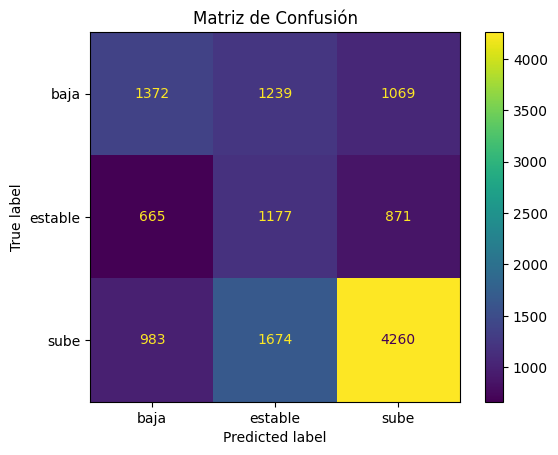

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=modelo.classes_
)

disp.plot()

plt.title("Matriz de Confusión")
plt.show()

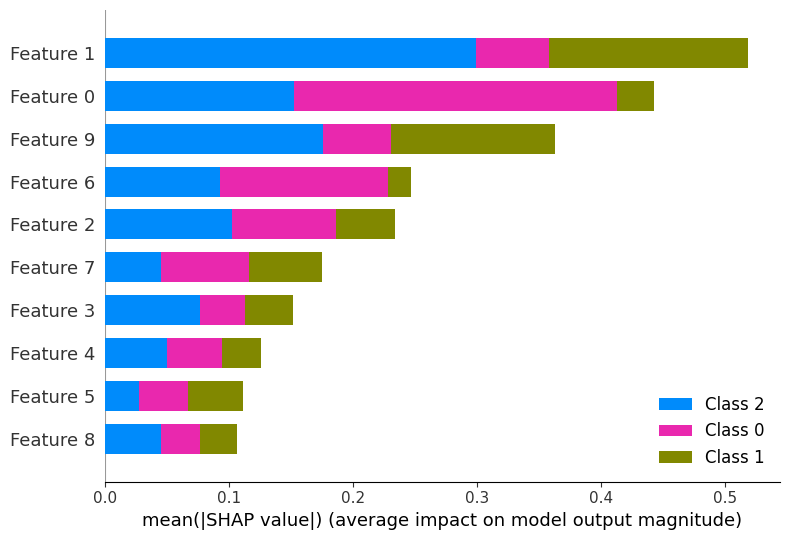

In [40]:
import shap

explainer = shap.TreeExplainer(modelo)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)